# CGS698C – Assignment 05
240770,Praneel Iralapalle




In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pymc as pm
import arviz as az

np.random.seed(42)
az.style.use("arviz-darkgrid")

### Part 1: Linear Regression — Power Posing & Testosterone

Hypothesis & Target Variable
We are testing if high power poses increase testosterone more than low ones. To isolate the treatment effect and strip out baseline noise, we model the absolute change:

$$\Delta T_i = \text{testm2}_i - \text{testm1}_i$$

The Model
$$\Delta T_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta \cdot \text{hptreat}_i$$

(Note: `hptreat` is 1 for High, 0 for Low).
$\beta$ is our target metric—it measures the extra testosterone boost caused by the high power pose.

Priors:
Normal salivary testosterone sits around 10–120 pg/ml. A quick lab test won't trigger a 500 pg/ml spike, so we use weakly informative priors to block physically impossible values without overriding the data:
* $\alpha$ and $\beta \sim \text{Normal}(0, 20)$: Centers at zero change, with 95% of the mass within a plausible ±40 pg/ml range.
* $\sigma \sim \text{Exponential}(0.05)$: Keeps the residual noise realistic (mostly under 40 pg/ml).

Interpreting the Output
* $\beta > 0$: Indicates the high pose group saw a larger testosterone increase.
* We'll use the 95% HDI and $P(\beta > 0)$ to measure confidence. A probability well above 0.5 (e.g., $\ge 0.85$) shows solid support.
* *Caveat:* With only $n = 39$, posterior uncertainty will be high. All conclusions here are tentative.

### 1.1 Load & Prepare Data

In [4]:
df = pd.read_csv("df_powerpose.csv")
print(df.head())

# Outcome: change in testosterone
df["delta_test"] = df["testm2"] - df["testm1"]
df["treat"]      = (df["hptreat"] == "High").astype(int)   # High=1, Low=0

print("\nMean change by treatment group:")
print(df.groupby("hptreat")["delta_test"].agg(["mean", "std", "count"]))

   Unnamed: 0  id hptreat  female  age     testm1     testm2
0           2  29    High    Male   19  38.724998  62.375000
1           3  30     Low  Female   20  32.770000  29.235001
2           4  31    High  Female   20  32.320000  27.510000
3           5  32     Low  Female   18  17.995001  28.655001
4           7  34     Low  Female   21  73.580002  44.669998

Mean change by treatment group:
            mean        std  count
hptreat                           
High     4.46800  20.074136     20
Low     -4.36658  20.273385     19


### 1.2 Prior Predictive Check

/tmp/ipykernel_70992/3052501144.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


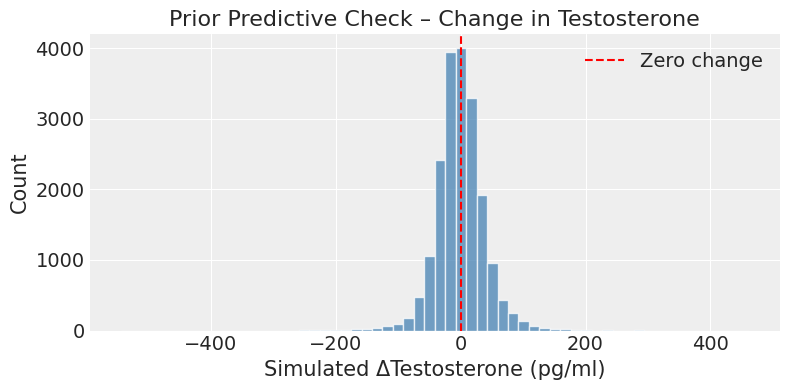

In [5]:
with pm.Model() as model_p1_prior:
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta  = pm.Normal("beta",  mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.05)

    mu = alpha + beta * df["treat"].values
    pm.Normal("y", mu=mu, sigma=sigma, observed=df["delta_test"].values)

    prior_checks = pm.sample_prior_predictive(samples=500, random_seed=42)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_checks.prior_predictive["y"].values.flatten(),
        bins=60, alpha=0.75, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero change")
ax.set_xlabel("Simulated ΔTestosterone (pg/ml)")
ax.set_ylabel("Count")
ax.set_title("Prior Predictive Check – Change in Testosterone")
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Fit the Model

In [6]:
with pm.Model() as model_p1:
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta  = pm.Normal("beta",  mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.05)

    mu = alpha + beta * df["treat"].values
    pm.Normal("y", mu=mu, sigma=sigma, observed=df["delta_test"].values)

    trace_p1 = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                         random_seed=42, progressbar=True)

print(az.summary(trace_p1, var_names=["alpha", "beta", "sigma"], round_to=3))

Output()

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  -3.802  4.518 -12.255    4.710      0.067    0.054  4536.839  4481.429   
beta    7.842  6.241  -4.153   19.302      0.095    0.071  4333.190  4608.571   
sigma  20.572  2.435  16.179   25.176      0.035    0.033  5064.102  4904.337   

       r_hat  
alpha  1.001  
beta   1.000  
sigma  1.001  


### 1.4 Trace Plots & Diagnostics

/tmp/ipykernel_70992/3368505234.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


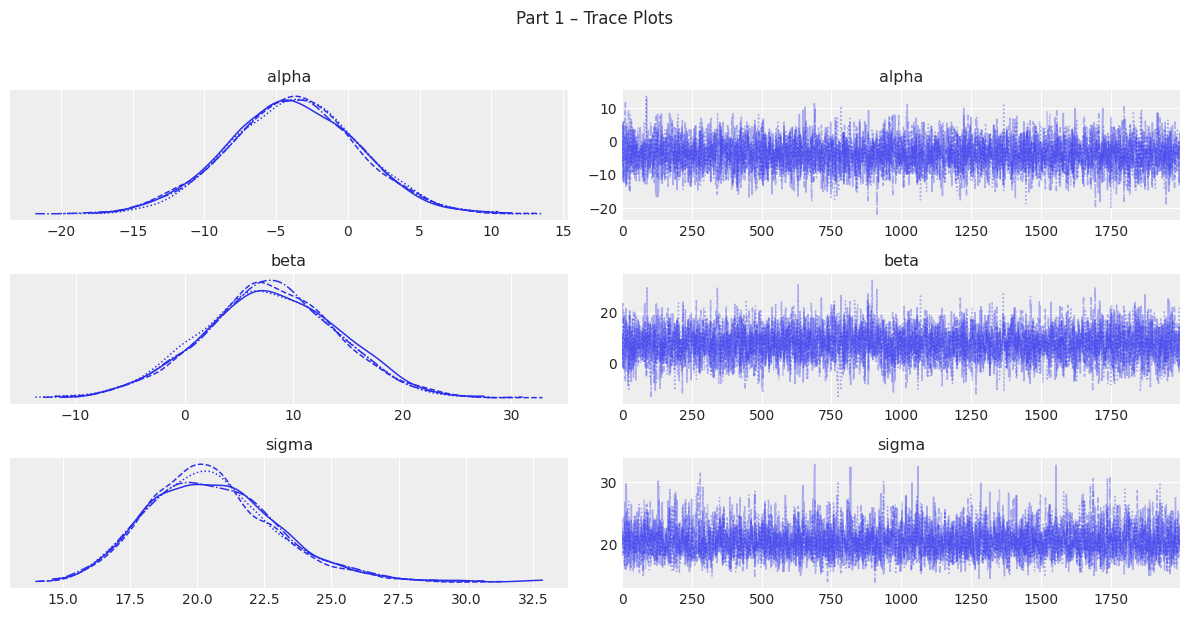

In [7]:
az.plot_trace(trace_p1, var_names=["alpha", "beta", "sigma"])
plt.suptitle("Part 1 – Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Posterior of Treatment Effect (β)

Posterior mean of β : 7.842 pg/ml
95% HDI             : [-4.334, 20.118]
P(High > Low)       : 0.892


/tmp/ipykernel_70992/3205694853.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


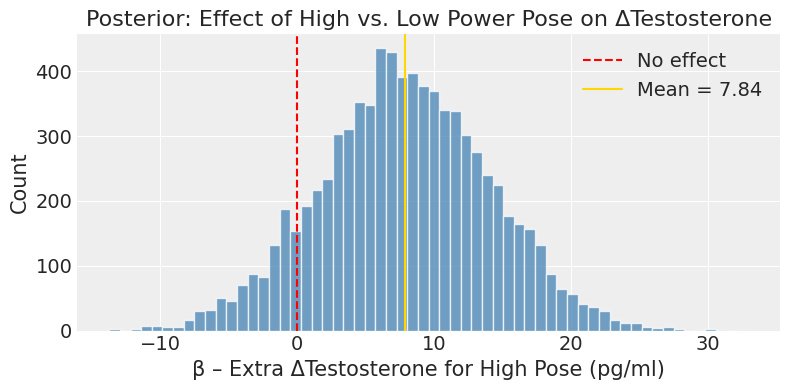

In [8]:
beta_samples = trace_p1.posterior["beta"].values.flatten()
prob_positive = np.mean(beta_samples > 0)
hdi_95 = az.hdi(beta_samples, hdi_prob=0.95)

print(f"Posterior mean of β : {beta_samples.mean():.3f} pg/ml")
print(f"95% HDI             : [{hdi_95[0]:.3f}, {hdi_95[1]:.3f}]")
print(f"P(High > Low)       : {prob_positive:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(beta_samples, bins=60, alpha=0.75, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="No effect")
ax.axvline(beta_samples.mean(), color="gold", linewidth=1.5,
           label=f"Mean = {beta_samples.mean():.2f}")
ax.set_xlabel("β – Extra ΔTestosterone for High Pose (pg/ml)")
ax.set_ylabel("Count")
ax.set_title("Posterior: Effect of High vs. Low Power Pose on ΔTestosterone")
ax.legend()
plt.tight_layout()
plt.show()

### 1.6 Posterior Predictive Check

Output()

/tmp/ipykernel_70992/4267611983.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


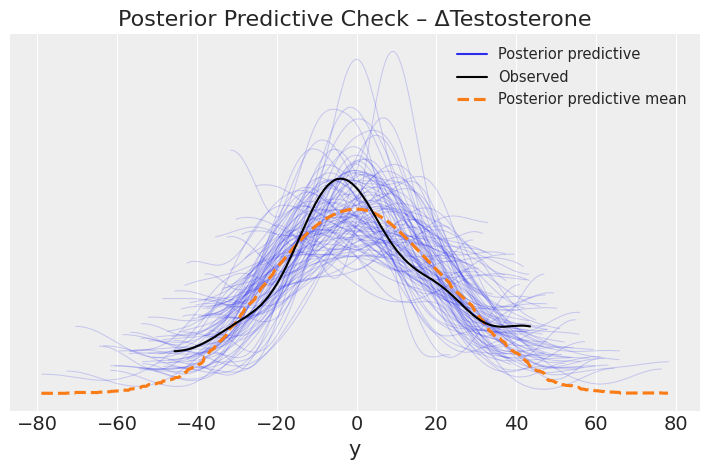

In [9]:
with model_p1:
    ppc_p1 = pm.sample_posterior_predictive(trace_p1, random_seed=42)

az.plot_ppc(ppc_p1, observed=True, num_pp_samples=100)
plt.title("Posterior Predictive Check – ΔTestosterone")
plt.tight_layout()
plt.show()

---
## Part 2: Poisson Regression — Crossing Dependencies



### Exercise 2.1 — Model Function

#### Theory

The generative model is:

$$N_i \sim \text{Poisson}(\lambda_i), \quad \log \lambda_i = \alpha + \beta L_i$$

The **log link** guarantees λ > 0 for all parameter values. Exponentiating:

$$\lambda_i = e^{\alpha} \cdot e^{\beta L_i}$$

This is a **multiplicative** model: each additional word multiplies the expected crossing rate by $e^\beta$. The function below samples one realisation from this model for a given sentence length.

In [22]:
def generate_crossings(length: int, alpha: float, beta: float) -> int:

    lam = np.exp(alpha + beta * length)
    return np.random.poisson(lam)

# Quick demonstration
print("Sentence length=10, α=0.15, β=0.25 →", generate_crossings(10, 0.15, 0.25), "crossings")
print("Sentence length=4,  α=0.15, β=0.25 →", generate_crossings(4,  0.15, 0.25), "crossings")
print("Sentence length=20, α=0.15, β=0.25 →", generate_crossings(20, 0.15, 0.25), "crossings")

Sentence length=10, α=0.15, β=0.25 → 18 crossings
Sentence length=4,  α=0.15, β=0.25 → 1 crossings
Sentence length=20, α=0.15, β=0.25 → 165 crossings


### Exercise 2.2 — Prior Predictions at Sentence Length = 4

#### Theory

The priors are **truncated normals with lower bound 0**, ensuring rate parameters stay positive:

$$\alpha \sim \text{Normal}_{lb=0}(0.15,\ 0.1)$$
$$\beta  \sim \text{Normal}_{lb=0}(0.25,\ 0.05)$$

**Why these values make sense:**

- $\alpha = 0.15 \Rightarrow e^{0.15} \approx 1.16$ expected crossings at the reference length — a small but non-zero baseline rate.
- $\beta = 0.25 \Rightarrow e^{0.25} \approx 1.28$ — each extra word multiplies the expected rate by ~1.28.
- The lower bound of 0 prevents negative rates, which would be meaningless for a Poisson rate.

At L = 4 the prior predictive should concentrate on **low counts (0–3)**, consistent with the linguistic observation that short sentences rarely exhibit crossing dependencies.

Prior predictive at L = 4:
  Mean    : 3.284
  Median  : 3
  P(N=0)  : 0.046
  P(N>5)  : 0.129


/tmp/ipykernel_70992/3328108382.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


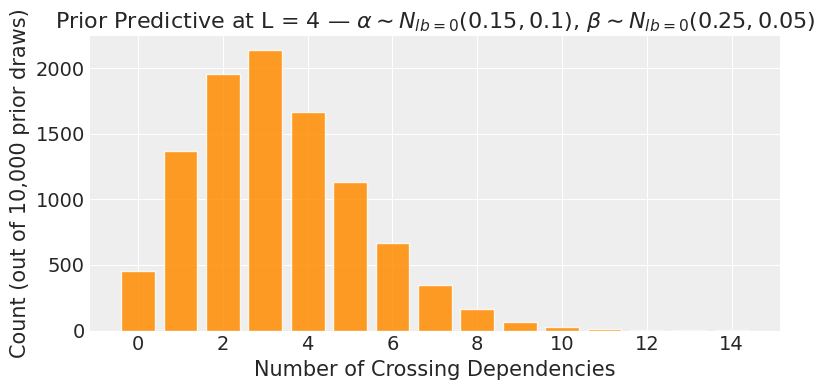

In [23]:
def sample_truncnorm_lb0(mu, sigma, n):
    """Sample from Normal(mu, sigma) truncated at lower bound = 0."""
    lower_clip = (0 - mu) / sigma
    return stats.truncnorm.rvs(lower_clip, np.inf, loc=mu, scale=sigma, size=n)

N_PRIOR = 10_000
alpha_prior = sample_truncnorm_lb0(0.15, 0.1,  N_PRIOR)
beta_prior  = sample_truncnorm_lb0(0.25, 0.05, N_PRIOR)

crossings_at_4 = np.random.poisson(np.exp(alpha_prior + beta_prior * 4))

print(f"Prior predictive at L = 4:")
print(f"  Mean    : {crossings_at_4.mean():.3f}")
print(f"  Median  : {np.median(crossings_at_4):.0f}")
print(f"  P(N=0)  : {np.mean(crossings_at_4 == 0):.3f}")
print(f"  P(N>5)  : {np.mean(crossings_at_4 > 5):.3f}")

vals, counts = np.unique(crossings_at_4, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vals, counts, color="darkorange", alpha=0.85, edgecolor="white")
ax.set_xlabel("Number of Crossing Dependencies")
ax.set_ylabel("Count (out of 10,000 prior draws)")
ax.set_title(r"Prior Predictive at L = 4 — $\alpha \sim N_{lb=0}(0.15, 0.1)$, $\beta \sim N_{lb=0}(0.25, 0.05)$")
plt.tight_layout()
plt.show()

### Exercise 2.3 — Fit Models M1 and M2

#### Theory

##### Model M1 — Language-independent rate

$$\log \lambda_{i,j} = \alpha + \beta L_{i,j}$$

**Assumption:** The rate of crossings depends only on sentence length; it is identical for English and German.

| Parameter | Interpretation |
|-----------|---------------|
| α | Log expected crossings at mean sentence length, pooled over both languages |
| β | Change in log-rate per extra word; $e^\beta$ is the multiplicative factor per word |

##### Model M2 — Language-specific interaction

$$\log \lambda_{i,j} = \alpha + \beta L_{i,j} + \beta_{\text{lang}} R_j + \beta_{\text{interact}} L_{i,j} \cdot R_j$$

where $R_j = 0$ for English and $R_j = 1$ for German.

| Parameter | Interpretation |
|-----------|---------------|
| α | Log expected crossings at mean sentence length for **English** |
| β | Slope for English |
| $\beta_{\text{lang}}$ | German offset at average sentence length (log scale) |
| $\beta_{\text{interact}}$ | **Difference in slopes** between German and English |

- $\beta_{\text{interact}} > 0$ → German crossings grow faster with sentence length than English  
- $\beta_{\text{interact}} < 0$ → German crossings grow more slowly  
- $\beta_{\text{interact}} \approx 0$ → Both languages share the same slope (M2 collapses to M1)

#### Load & Visualise Data

  Language  s.id  s.length  nCross
0   German     1         2       0
1   German     2         2       1
2   German     3         2       0
3   German     4         2       0
4   German     5         2       2

Language counts:
Language
German     950
English    950
Name: count, dtype: int64


/tmp/ipykernel_70992/2836784256.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


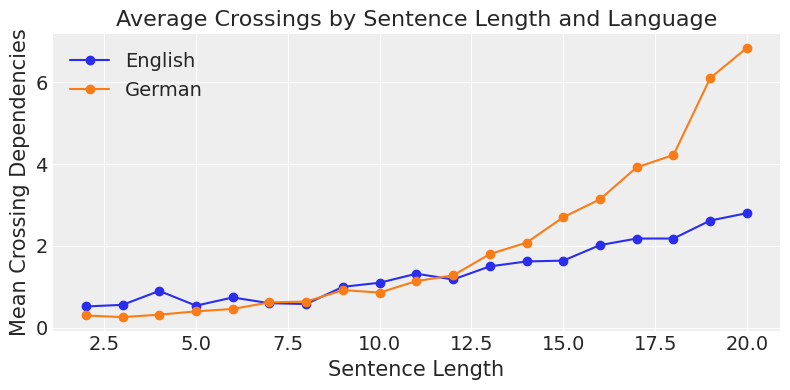

In [12]:
obs = pd.read_csv("crossings.csv")
print(obs.head())
print("\nLanguage counts:")
print(obs["Language"].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
for lang, grp in obs.groupby("Language"):
    s = grp.groupby("s.length")["nCross"].mean().reset_index()
    ax.plot(s["s.length"], s["nCross"], marker="o", label=lang)
ax.set_xlabel("Sentence Length")
ax.set_ylabel("Mean Crossing Dependencies")
ax.set_title("Average Crossings by Sentence Length and Language")
ax.legend()
plt.tight_layout()
plt.show()

# Centre sentence length; encode language
obs["s_length_c"] = obs["s.length"] - obs["s.length"].mean()
obs["lang"]       = (obs["Language"] == "German").astype(int)

s_length_c  = obs["s_length_c"].values
lang_ind    = obs["lang"].values
n_crossings = obs["nCross"].values

#### Fit Model M1

In [13]:
with pm.Model() as model_m1:
    alpha_m1 = pm.Normal("alpha", mu=0.15, sigma=0.1)
    beta_m1  = pm.Normal("beta",  mu=0.0,  sigma=0.15)

    lam_m1 = pm.math.exp(alpha_m1 + beta_m1 * s_length_c)
    pm.Poisson("y", mu=lam_m1, observed=n_crossings)

    trace_m1 = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                         random_seed=42, progressbar=True)

print("Model M1 – Posterior Summary:")
print(az.summary(trace_m1, var_names=["alpha", "beta"], round_to=3))

Output()

Model M1 – Posterior Summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.197  0.023   0.154    0.241        0.0      0.0  2568.945  3636.043   
beta   0.150  0.004   0.143    0.157        0.0      0.0  2561.454  3981.782   

       r_hat  
alpha  1.001  
beta   1.001  


#### Fit Model M2

In [14]:
with pm.Model() as model_m2:
    alpha_m2   = pm.Normal("alpha",         mu=0.15, sigma=0.1)
    beta_m2    = pm.Normal("beta",          mu=0.0,  sigma=0.15)
    beta_lang  = pm.Normal("beta_lang",     mu=0.0,  sigma=0.15)
    beta_inter = pm.Normal("beta_interact", mu=0.0,  sigma=0.15)

    log_lam2 = (alpha_m2
                + beta_m2    * s_length_c
                + beta_lang  * lang_ind
                + beta_inter * s_length_c * lang_ind)
    pm.Poisson("y", mu=pm.math.exp(log_lam2), observed=n_crossings)

    trace_m2 = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                         random_seed=42, progressbar=True)

print("Model M2 – Posterior Summary:")
print(az.summary(trace_m2,
                 var_names=["alpha", "beta", "beta_lang", "beta_interact"],
                 round_to=3))

Output()

Model M2 – Posterior Summary:
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha          0.160  0.030   0.103    0.215      0.000      0.0  3735.125   
beta           0.097  0.005   0.087    0.107      0.000      0.0  3494.879   
beta_lang      0.027  0.045  -0.056    0.110      0.001      0.0  3441.258   
beta_interact  0.096  0.008   0.081    0.110      0.000      0.0  3256.237   

               ess_tail  r_hat  
alpha          4478.792  1.002  
beta           4535.454  1.000  
beta_lang      4414.896  1.001  
beta_interact  3492.350  1.001  


#### Trace Plots

/tmp/ipykernel_70992/498209388.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


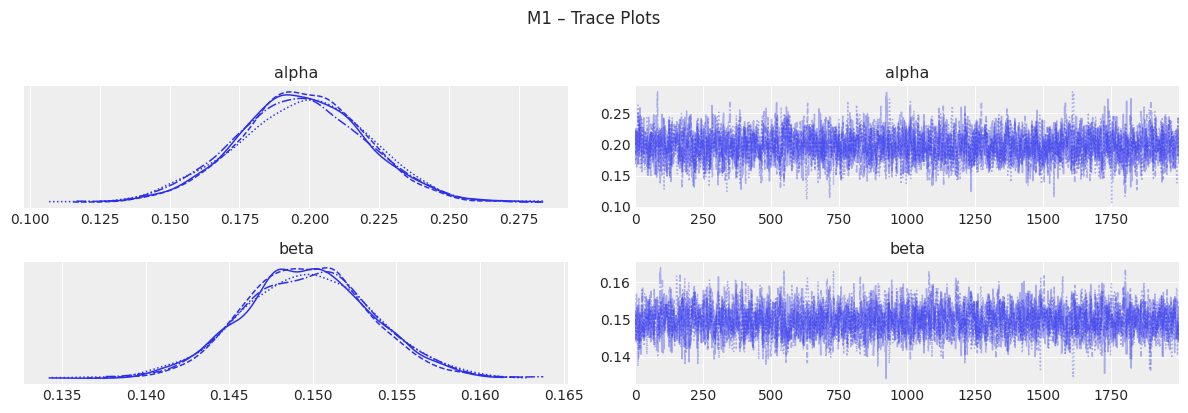

/tmp/ipykernel_70992/498209388.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


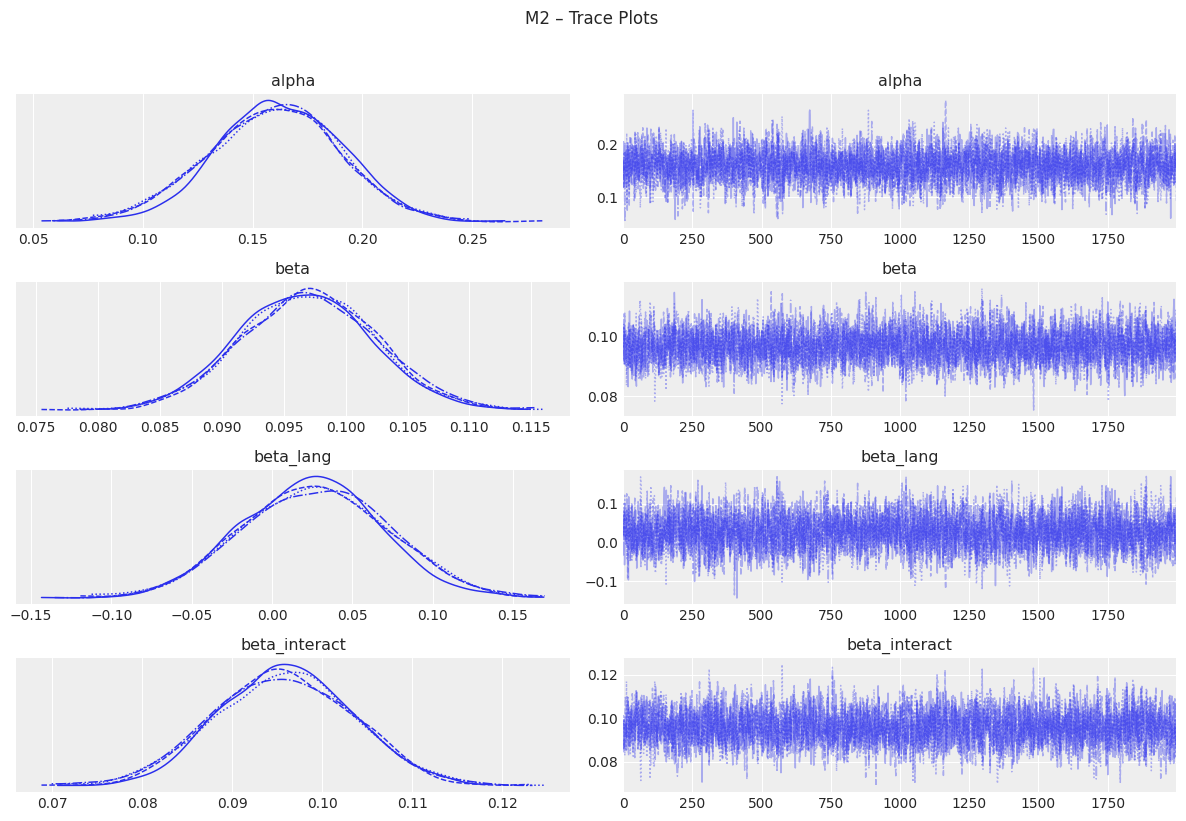

In [15]:
az.plot_trace(trace_m1, var_names=["alpha", "beta"])
plt.suptitle("M1 – Trace Plots", y=1.02)
plt.tight_layout(); plt.show()

az.plot_trace(trace_m2, var_names=["alpha", "beta", "beta_lang", "beta_interact"])
plt.suptitle("M2 – Trace Plots", y=1.02)
plt.tight_layout(); plt.show()

#### Posterior Predictive Checks

Output()

Output()

/tmp/ipykernel_70992/1710078622.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


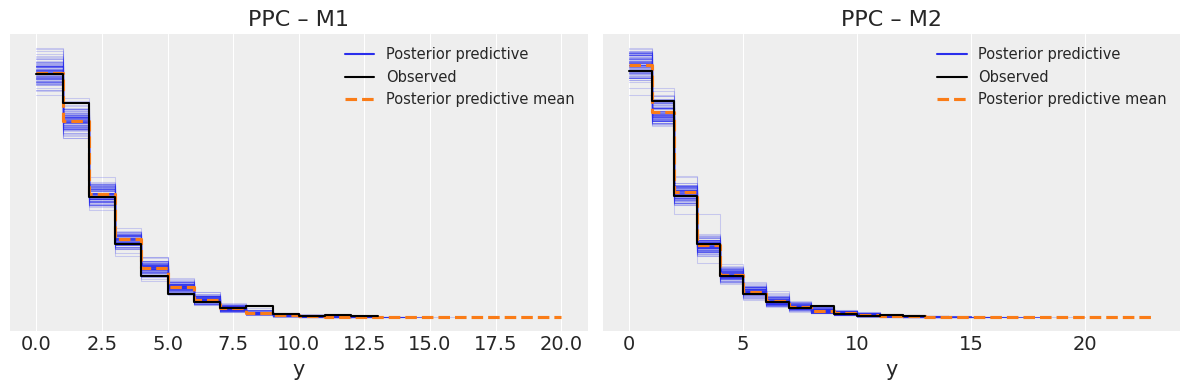

In [16]:
with model_m1:
    ppc_m1 = pm.sample_posterior_predictive(trace_m1, random_seed=42)
with model_m2:
    ppc_m2 = pm.sample_posterior_predictive(trace_m2, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
az.plot_ppc(ppc_m1, ax=axes[0], num_pp_samples=100); axes[0].set_title("PPC – M1")
az.plot_ppc(ppc_m2, ax=axes[1], num_pp_samples=100); axes[1].set_title("PPC – M2")
plt.tight_layout(); plt.show()

### Exercise 2.4 — 5-Fold Cross-Validation

#### Theory

5-fold CV splits the data into training (80%) and test (20%) folds. For each fold both models are fit on training data and evaluated on held-out test data using the **log pointwise predictive density (LPPD)**:

$$\text{LPPD} = \sum_{i \in \text{test}} \log \left( \frac{1}{S} \sum_{s=1}^{S} p(y_i \mid \theta^{(s)}) \right)$$

where $\theta^{(s)}$ are posterior draws and $p(y \mid \theta)$ is the Poisson likelihood. LPPDs are summed across folds to give the **Expected Log Predictive Density (ELPD)**. Then:

$$\Delta\text{ELPD} = \text{ELPD}_{M2} - \text{ELPD}_{M1}$$

| Value | Conclusion |
|-------|------------|
| ΔELPD > 0 | M2 predicts better → language × length interaction is warranted |
| ΔELPD ≈ 0 | Models are comparable; interaction adds no predictive benefit |
| ΔELPD < 0 | M1 predicts better → simpler model is preferred |

In [17]:
def lppd_m1(post_alpha, post_beta, s_c, y_obs):
    lam = np.exp(post_alpha + post_beta * s_c)
    return np.log(np.mean(stats.poisson.pmf(y_obs, lam)))

def lppd_m2(post_alpha, post_beta, post_bl, post_bi, s_c, lang_val, y_obs):
    lam = np.exp(post_alpha + post_beta*s_c + post_bl*lang_val + post_bi*s_c*lang_val)
    return np.log(np.mean(stats.poisson.pmf(y_obs, lam)))

K         = 5
n_obs     = len(obs)
shuffled  = np.random.permutation(n_obs)
fold_size = n_obs // K

lpds_m1 = []
lpds_m2 = []

for k in range(K):
    test_idx  = shuffled[k * fold_size : (k+1) * fold_size]
    train_idx = np.setdiff1d(np.arange(n_obs), test_idx)

    obs_train = obs.iloc[train_idx]
    obs_test  = obs.iloc[test_idx]

    s_tr = obs_train["s_length_c"].values;  l_tr = obs_train["lang"].values;  y_tr = obs_train["nCross"].values
    s_te = obs_test["s_length_c"].values;   l_te = obs_test["lang"].values;   y_te = obs_test["nCross"].values

    # Fit M1 on training fold
    with pm.Model():
        a1 = pm.Normal("alpha", mu=0.15, sigma=0.1)
        b1 = pm.Normal("beta",  mu=0.0,  sigma=0.15)
        pm.Poisson("y", mu=pm.math.exp(a1 + b1 * s_tr), observed=y_tr)
        tr1 = pm.sample(1000, tune=500, chains=2, progressbar=False, random_seed=k)

    # Fit M2 on training fold
    with pm.Model():
        a2 = pm.Normal("alpha",         mu=0.15, sigma=0.1)
        b2 = pm.Normal("beta",          mu=0.0,  sigma=0.15)
        bl = pm.Normal("beta_lang",     mu=0.0,  sigma=0.15)
        bi = pm.Normal("beta_interact", mu=0.0,  sigma=0.15)
        pm.Poisson("y", mu=pm.math.exp(a2 + b2*s_tr + bl*l_tr + bi*s_tr*l_tr), observed=y_tr)
        tr2 = pm.sample(1000, tune=500, chains=2, progressbar=False, random_seed=k)

    pa1 = tr1.posterior["alpha"].values.flatten(); pb1 = tr1.posterior["beta"].values.flatten()
    pa2 = tr2.posterior["alpha"].values.flatten(); pb2 = tr2.posterior["beta"].values.flatten()
    pbl = tr2.posterior["beta_lang"].values.flatten(); pbi = tr2.posterior["beta_interact"].values.flatten()

    fold_lppd_m1 = sum(lppd_m1(pa1, pb1, s_te[i], y_te[i]) for i in range(len(y_te)))
    fold_lppd_m2 = sum(lppd_m2(pa2, pb2, pbl, pbi, s_te[i], l_te[i], y_te[i]) for i in range(len(y_te)))

    lpds_m1.append(fold_lppd_m1)
    lpds_m2.append(fold_lppd_m2)
    print(f"Fold {k+1}: LPPD M1 = {fold_lppd_m1:.2f} | LPPD M2 = {fold_lppd_m2:.2f}")

Fold 1: LPPD M1 = -590.54 | LPPD M2 = -544.26
Fold 2: LPPD M1 = -571.21 | LPPD M2 = -546.67
Fold 3: LPPD M1 = -557.99 | LPPD M2 = -531.14
Fold 4: LPPD M1 = -552.83 | LPPD M2 = -538.12
Fold 5: LPPD M1 = -543.39 | LPPD M2 = -524.75


ELPD  M1 : -2815.95
ELPD  M2 : -2684.92
Δ ELPD   : 131.03  (M2 − M1)
→ M2 outperforms M1 by 131.03 ELPD units.


/tmp/ipykernel_70992/4040375134.py:18: UserWarning: The figure layout has changed to tight
  ax.legend(); plt.tight_layout(); plt.show()


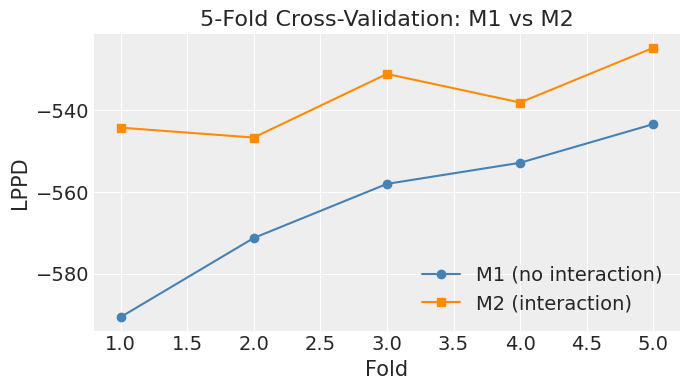

In [26]:
elpd_m1    = sum(lpds_m1)
elpd_m2    = sum(lpds_m2)
delta_elpd = elpd_m2 - elpd_m1

print(f"ELPD  M1 : {elpd_m1:.2f}")
print(f"ELPD  M2 : {elpd_m2:.2f}")
print(f"Δ ELPD   : {delta_elpd:.2f}  (M2 − M1)")

print(f"→ M2 {'outperforms' if delta_elpd > 0 else 'does not outperform'} M1 by {abs(delta_elpd):.2f} ELPD units.")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
folds = np.arange(1, K+1)
ax.plot(folds, lpds_m1, "o-", label="M1 (no interaction)", color="steelblue")
ax.plot(folds, lpds_m2, "s-", label="M2 (interaction)",    color="darkorange")
ax.set_xlabel("Fold"); ax.set_ylabel("LPPD")
ax.set_title("5-Fold Cross-Validation: M1 vs M2")
ax.legend(); plt.tight_layout(); plt.show()